# Waveform I/O for RIT catalogue.
## Authors: Vaishak Prasad

[comment]: <> (Abstract: TODO)

**Notebook Status:** <font color='green'><b> Production </b></font> 

**Notes:** 
Last checked on 29 Oct 2022

## Introduction:
This notebook describes the routines for 

1. Loading RIT waveform data (Strain $rh/M$ and $\Psi_4$) into numpy arrays.
2. Loading into waveforms modes_array
3. Trasformations between harmonic and angular basis.

<a id='toc1'></a>

# Table of Contents
$$\label{toc1}$$

This notebook is organized as follows:

1. [Sec 1](#imports): Initialize the required Python libraries.
1. [Sec 2](#psi4)  : $\Psi_4$.
    1. [Sec 2.1](#one_psi4)           : Load and plot a single mode.
    1. [Sec 2.2](#all_psi4) : Load all modes into a modes_array object. 
1. [Sec 3](#strain) : Strain.
    1. [Sec 3.1](#one_strain)         : Load and plot a single mode.
    1. [Sec 3.2](#all_strain) : Load all modes into a modes_array object. <font color='red'><b> DIY! </b></font> 
1. [Sec 4](#trans) : Harmonic to angular basis.
    1. [Sec 4.1](#trans1)         : Transformation.
    2. [Sec 4.2](#trans2)         : Reverse transformation.

# Imports

<a id='imports'></a>

# Sec 1: Initialize the required Python libraries and functions. [Back to [top](#toc1)\]
$$\label{imports}$$

In [2]:
import numpy as np
import waveformtools
import matplotlib.pyplot as plt

#####################
# matplotlib presets
#########################################

labelsize=16
labelpad=14

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({"figure.figsize" : (8,6)})
plt.rcParams.update({"axes.grid" : True})
plt.rcParams.update({"axes.labelpad" : labelpad})
plt.rcParams.update({"axes.labelsize" : labelsize})
plt.rcParams.update({"figure.autolayout" : True})
plt.rcParams.update({"grid.alpha" : 0.3})
plt.rcParams.update({"grid.alpha" : 0.3})
plt.rcParams.update({'legend.markerscale': 12})

## Misc functions

In [3]:
def get_centered_taxis(time_ax, amps):
    ''' Center the time axis about the max amp epoch.
        
        Parameters
        ##########
        
        time_ax (1d) : The time axis as a list or a 1d array.
        amps (1d) : The amplitudes as a list or a 1d array.
        
        Returns
        #######
        
        time_cen (1d) : An array of new time axis.
    '''
    amps_max    = np.argmax(abs(amps))
    time_max    = time_ax[amps_max]
    time_cen    = time_ax-time_max
    return time_cen

<a id='psi4'></a>

## Sec 2: $\Psi_4$ \[Back to [top](#toc1)\]
$$\label{psi4}$$


Here the $\Psi_4$ data from a simulation from the RIT catalogue is loaded info wavefoms modes_array.

<a id='one_psi4'></a>
## Load one mode.

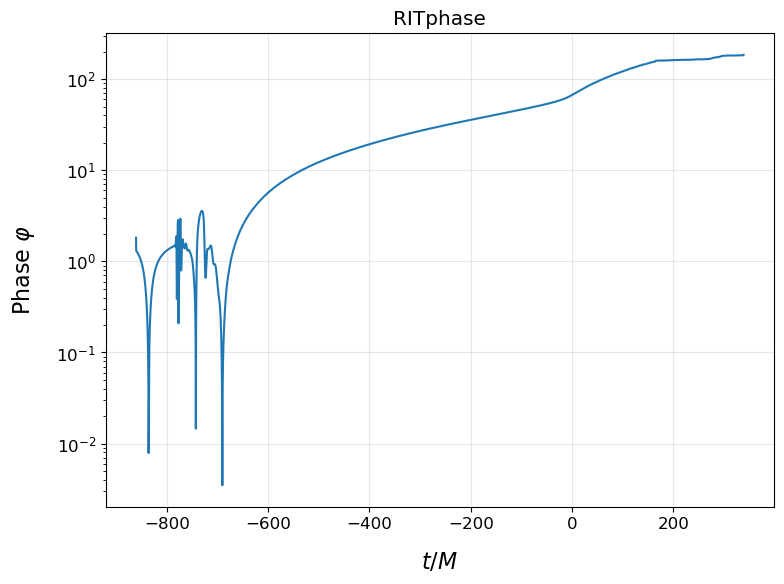

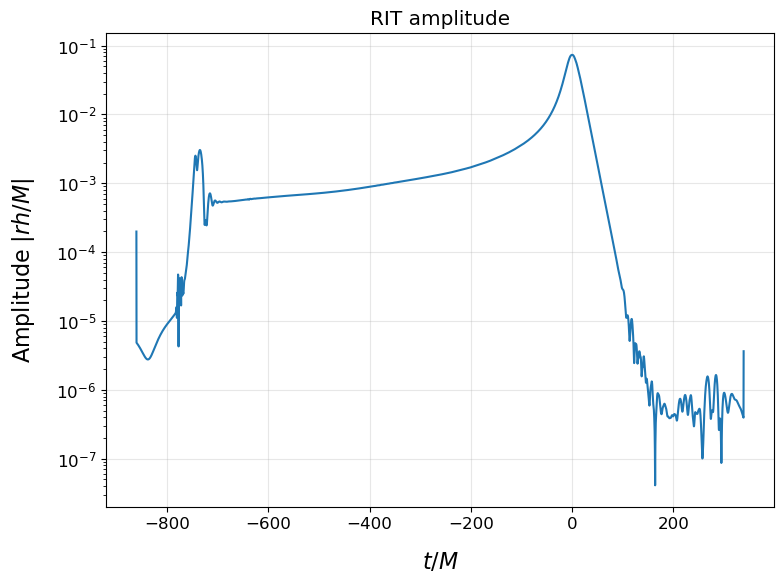

In [4]:
################################
# Set path variables
################################

psi4_data_dir = '/home/vaishakprasad/Downloads/waveform_extraction/RIT/q1a0_a/Psi4/'

# Name of the psi4 data. 
# Here, l=2, m=2 data extrapolated to infinity is loaded.
ell = 2
emm = 2
psi4_file_name = f'rPsi4_l{ell}_m{emm}_rInf.asc'

wf2_psi4_file_path = psi4_data_dir + psi4_file_name

##############################
# Read in the data
##############################

# Load the ASCII file
wf2_psi4_file = np.genfromtxt(wf2_psi4_file_path)

# Assign the time axis
wf2_psi4_time = wf2_psi4_file[:, 0]

######################
# Load phase data
######################

# Phase data
Yphase = wf2_psi4_file[:, 4]


################################
# Load amplitude data
################################

# Amplitude data
Yamp = wf2_psi4_file[:, 3]

######################################

# Center the time axis about merger
wf2_psi4_time_cen  = get_centered_taxis(wf2_psi4_time, Yamp)

# plot variables
Xphase        = wf2_psi4_time_cen
Xamp          = Xphase

lab     = 'RIT'

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.plot(Xphase, abs(Yphase))
ax.set_title(lab + 'phase')
ax.set_xlabel(r'$t/M$')
ax.set_ylabel(r'Phase $\varphi$')
plt.show()

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.plot(Xamp, abs(Yamp))
ax.set_title(lab + ' amplitude')
ax.set_xlabel(r'$t/M$')
ax.set_ylabel(r'Amplitude $\vert r h/M \vert$')
plt.show()

<a id='all_psi4'></a>
## Load $\Psi_4$ data of all available modes

1. Read in the data
2. Resample to uniform spacing
3. Load into modes_array

In [29]:
from waveformtools import waveforms
from waveformtools.waveforms import modes_array
# Max available mode l.
ell_max = 4

# Construct a modes list
wf2_modes_list = waveforms.construct_mode_list(ell_max = 4)

print('The modes list is', wf2_modes_list)

# For interpolation
from scipy.interpolate import interp1d

# Name of the run
alias = 'q1a0_a'

# Create a modes array
wf2 = modes_array(label=f'RIT_{alias}_rPsi4inf', data_dir=psi4_data_dir, modes_list=wf2_modes_list)

# Enforce only l>2 modes.
wf2_modes_list = [item for item in wf2_modes_list if item[0]>=2]



##########################################
# Read in the data
#########################################
print('Reading in modes...')
for ell, emm_list in wf2_modes_list:
    for emm in emm_list:
        
        print('Loading', ell, emm)
        # Construct file path
        wf2_psi4_file_path = psi4_data_dir + f'rPsi4_l{ell}_m{emm}_rInf.asc'
        # Read in the data
        wf2_psi4_file = np.genfromtxt(wf2_psi4_file_path)
        
        # Get time axis
        wf2_psi4_time = wf2_psi4_file[:, 0]
        
        # Create modes_array on first run
        if wf2.modes_data is None:
            print('Creating modes data')
            
            # Choose finest available timestep
            min_dt = round(min(np.diff(wf2_psi4_time)), 3)
            print('Resampling at finest timestep', min_dt)
            
            # New (resampled) time axis
            time_axis = np.arange(wf2_psi4_time[0], wf2_psi4_time[-1], min_dt)
            
            # Length of data.
            data_len = len(time_axis)
            
            # Create a modes array object
            wf2._create_modes_array(ell_max=ell_max, data_len=data_len)
            
            # Assign to it the time axis
            wf2.time_axis = time_axis
        
        
        ###############################
        # Load the phase data
        ##############################
        
        Yphase = wf2_psi4_file[:, 4]
        Yphase_interp_fun = interp1d(wf2_psi4_time, Yphase, kind='cubic')
        
        # Resample
        Yphase_resam = Yphase_interp_fun(wf2.time_axis)


        ###########################
        # Load the amplitude data
        ###########################
        Yamp = wf2_psi4_file[:, 3]
        Yamp_interp_fun = interp1d(wf2_psi4_time, Yamp, kind='cubic')
        
        # Resample
        Yamp_resam = Yamp_interp_fun(wf2.time_axis)
        wfmode = Yamp_resam * np.exp(1j*Yphase_resam)
        
        ###################################
        # Load the modes data
        ###################################
        
        wf2.set_mode_data(ell, emm, wfmode)
        

# Trim or recenter     
wf2.trim(trim_upto_time=0)


# Save the modes array as waveforms hdf file
wf2.save_modes(out_file_name='RIT_mp_psi4_resam_inf_new.h5')

The modes list is [[0, [0]], [1, [-1, 0, 1]], [2, [-2, -1, 0, 1, 2]], [3, [-3, -2, -1, 0, 1, 2, 3]], [4, [-4, -3, -2, -1, 0, 1, 2, 3, 4]]]
Reading in modes...
Loading 2 -2
Creating modes data
Resampling at finest timestep 0.25
Loading 2 -1
Loading 2 0
Loading 2 1
Loading 2 2
Loading 3 -3
Loading 3 -2
Loading 3 -1
Loading 3 0
Loading 3 1
Loading 3 2
Loading 3 3
Loading 4 -4
Loading 4 -3
Loading 4 -2
Loading 4 -1
Loading 4 0
Loading 4 1
Loading 4 2
Loading 4 3
Loading 4 4


<a id='strain'></a>

## Sec 3: $r h /M$ [Back to [top](#toc1)]jupyter
$$\label{strain}$$

Here the strain $r h/M$ data from a simulation from the RIT catalogue is loaded into numpy arrays.

<a id='one_strain'></a>
## Load one mode.

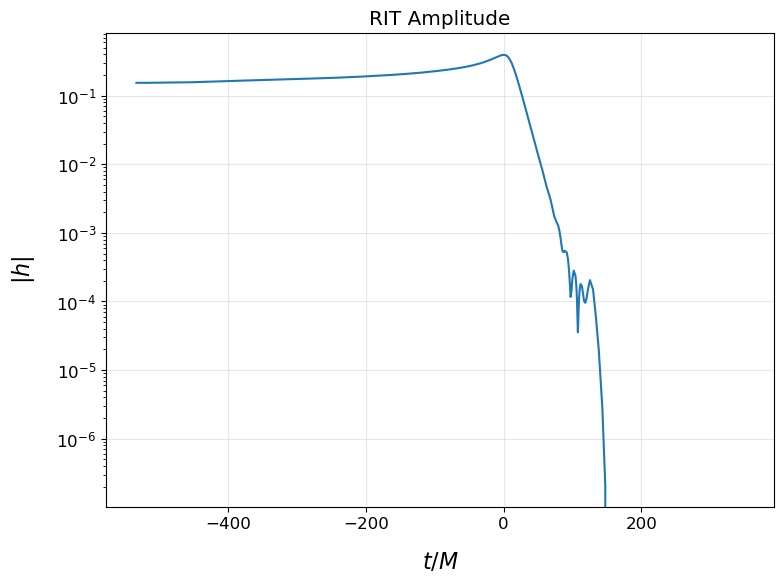

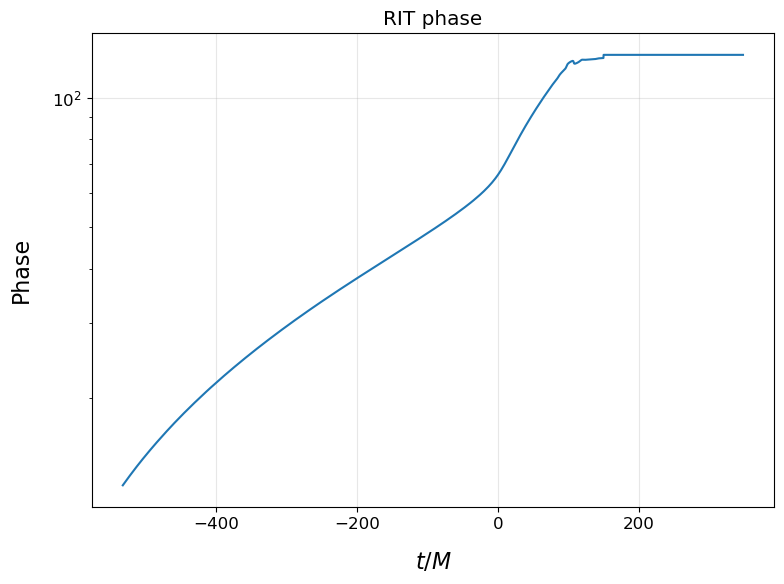

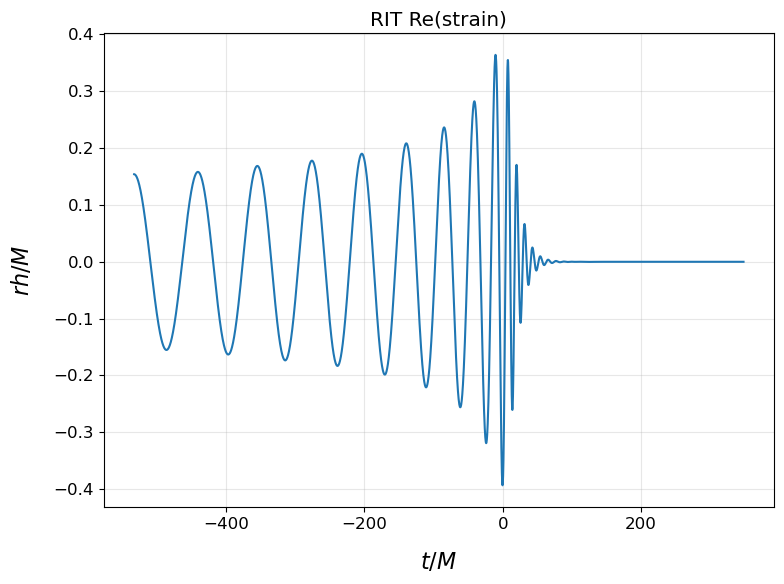

In [7]:
################################
# Set path variables
################################

strain_data_dir = f'/home/vaishakprasad/Downloads/waveform_extraction/RIT/{alias}/strain/'
strain_file_name = 'ExtrapStrain_RIT-BBH-0001-n100.h5'

wf2_strain_file_path = strain_data_dir + strain_file_name


################################################
# Load the strain data
###############################################

wf2_strain_file = h5py.File(wf2_strain_file_path)

wf2_strain_time = wf2_strain_file['NRTimes']

########################################
# Phase
########################################

fphase     = wf2_strain_file['phase_l2_m2']

Xphase = np.array(fphase['X'])
Yphase = np.array(fphase['Y'])

lab    = 'RIT '


#########################################
# Amplitude
#########################################

famp = wf2_strain_file['amp_l2_m2']

Xamp = np.array(famp['X'])
Yamp = np.array(famp['Y'])


##########################################
# Resample
##########################################

# time steppings
dt_phase = np.diff(Xphase)
dt_amp = np.diff(Xamp)

# Common limits for resampled time axis.
tmin = min(Xamp)
tmax = max(Xamp)

# uniform finest time step
dt_resam = min(np.amin(dt_amp), np.amin(dt_phase))

# Resam time axis
Xresam = np.arange(tmin, tmax, dt_resam)

Yamp_int_fn = interp1d(Xamp, Yamp, kind='cubic')
Yphase_int_fn = interp1d(Xphase, Yphase, kind='cubic')

Yamp_resam = Yamp_int_fn(Xresam)
Yphase_resam = Yphase_int_fn(Xresam)

wf2_strain       = Yamp_resam*np.exp(1j*Yphase_resam)
########################################
# Plot
########################################

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.plot(Xamp, abs(Yamp))
ax.set_title(lab + 'Amplitude')
ax.set_xlabel(r'$t/M$')
ax.set_ylabel(r'$\vert h \vert$')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots()
ax.set_yscale('log')
ax.plot(Xphase, abs(Yphase))
ax.set_title(lab + 'phase')
ax.set_xlabel(r'$t/M$')
ax.set_ylabel(r'Phase')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()


fig, ax = plt.subplots()
ax.plot(Xresam, wf2_strain.real)
ax.set_title(lab + 'Re(strain)')
ax.set_xlabel(r'$t/M$')
ax.set_ylabel(r'$rh/M$')
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()

<a id='trans'></a>

# Sec 3: Harmonic and angular basis [Back to [top](#toc1)]
$$\label{trans}$$

Here the transformation of the Weyl scalar $\Psi_4$ data from Spin-Weighted Spherical Harmonic (SWSH, $\ell, m$) basis to coordinate ($\theta, \phi$) basis is demonstrated.

In [22]:
# Create a staggered grid on a sphere.
from waveformtools import grids
# This creates a uniform angular grid stagerred about the north pole.
# By default, 4 ghost zones (2 on either sides)
# is alloted in each direction.
grid_info = grids.spherical_grid(ntheta=125, nphi=244)

theta, phi = grid_info.meshgrid

In [11]:
%%time
# Transform to angular coordinates.
waveform_sp = wf2.to_spherical_array(grid_info=grid_info)

CPU times: user 13.3 s, sys: 22.7 s, total: 36 s
Wall time: 37.3 s


<a id='trans1'></a>
## Carry out the transformation.

/tmp/ipykernel_10036/677803038.py:14: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)
/home/vaishakprasad/.conda/envs/pycbc/lib/python3.9/site-packages/ipympl/backend_nbagg.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')


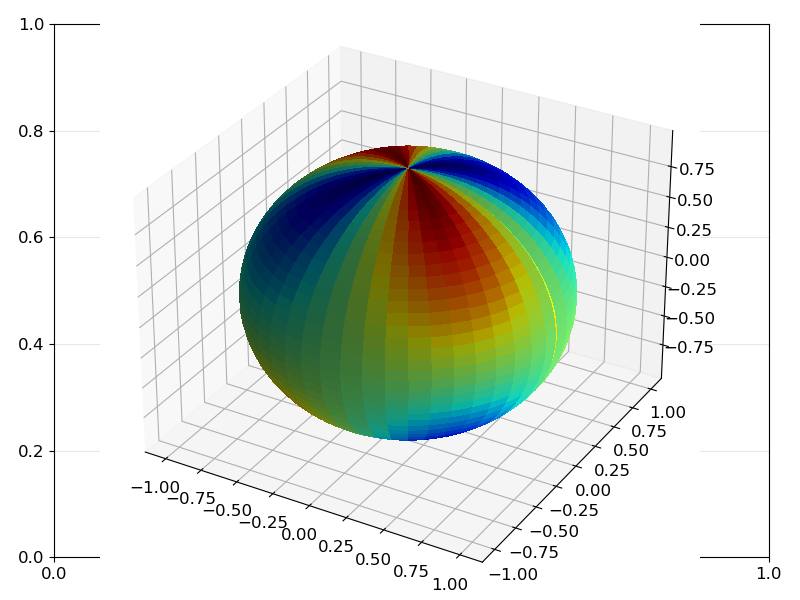

In [52]:
x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)


%matplotlib widget
import matplotlib
from mpl_toolkits.mplot3d import axes3d, Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax = Axes3D(fig)

# Plot the imaginary part of Psi4 
# at timestep
tstep = 100 

U = waveform_sp.data[:, :, tstep].imag

# Assign color dimension
color_dimension = U # change to desired fourth dimension

minn, maxx = color_dimension.min(), color_dimension.max()
norm = matplotlib.colors.Normalize(minn, maxx)

m = plt.cm.ScalarMappable(norm=norm, cmap='jet')
m.set_array([])

fcolors = m.to_rgba(color_dimension)

# Plot the surface.
surf = ax.plot_surface(x, y, z,
                       linewidth=0, antialiased=False, facecolors=fcolors)
plt.show()

<a id='trans2'></a>
## Reverse transformation.

In [32]:
%%time
wf2_2 = waveform_sp.to_modes_array()

CPU times: user 10.1 s, sys: 7.71 ms, total: 10.1 s
Wall time: 10.2 s


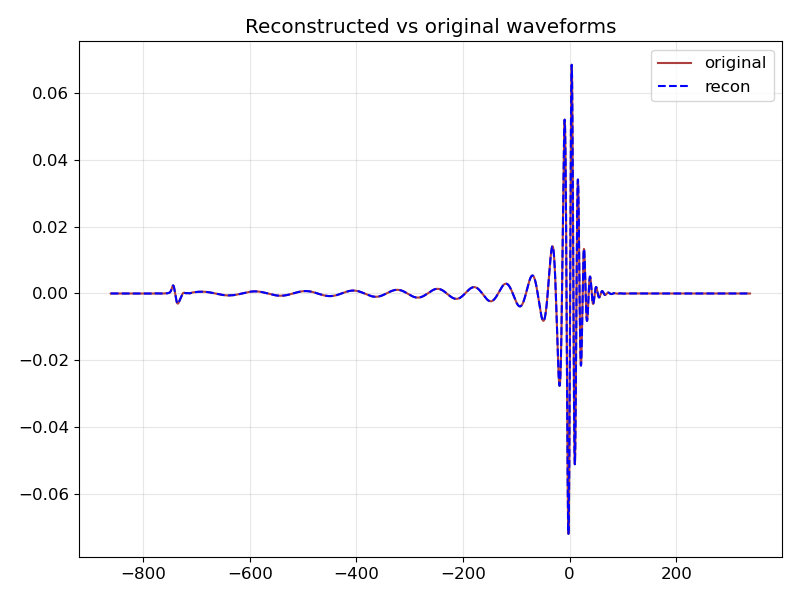

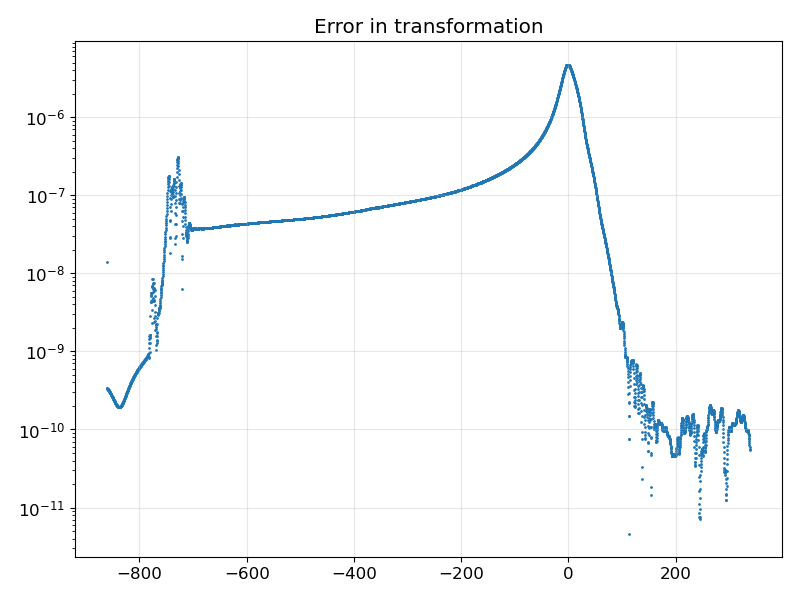

In [58]:
ell = 2
emm = -2
delta =  wf2.mode(ell, emm) - wf2_2.mode(ell, emm)

fig, ax = plt.subplots()

ax.plot(wf2.time_axis, wf2.mode(2, 2), label='original', alpha=0.9, c='brown')
ax.plot(wf2.time_axis, wf2_2.mode(2, 2), label='recon', linestyle='--', c='blue')
ax.set_title('Reconstructed vs original waveforms')
plt.legend()
plt.show()


fig, ax = plt.subplots()
ax.set_yscale('log')
ax.set_title('Error in transformation')
ax.scatter(wf2.time_axis, abs(delta), s=1)
plt.show()